# Seasonal Agriculture Performance Analysis
**VOIS AICTE Batch1 2026-2027 — Major Project**

This notebook analyzes how agricultural performance (yield, cost, revenue, profit, water use)
varies across seasons (Kharif, Rabi, Zaid), and what environmental and resource factors drive
those differences.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

## 1. Load the Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv


In [4]:
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
df.shape

(4000, 28)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


## 2. Data Cleaning

In [8]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [9]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()
df.shape

(4000, 28)

## 3. Outlier Detection

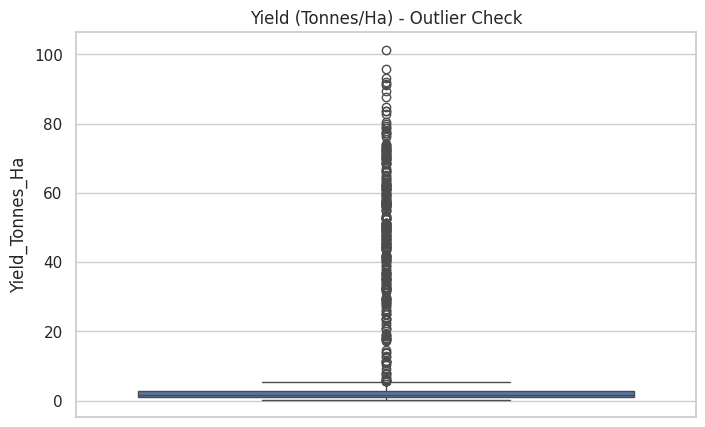

In [12]:
sns.boxplot(y='Yield_Tonnes_Ha', data=df)
plt.title('Yield (Tonnes/Ha) - Outlier Check')
plt.show()

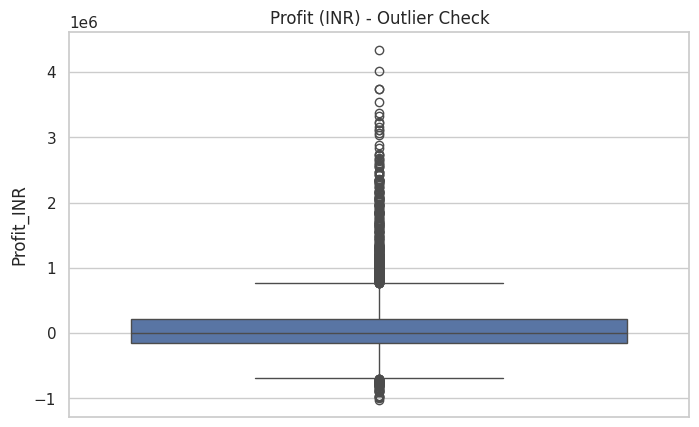

In [13]:
sns.boxplot(y='Profit_INR', data=df)
plt.title('Profit (INR) - Outlier Check')
plt.show()

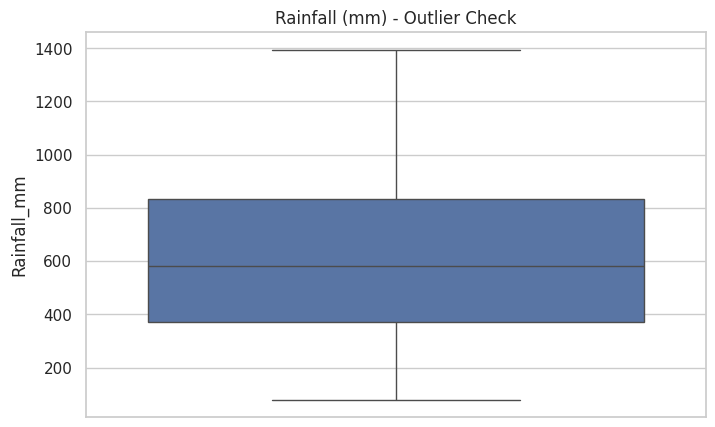

In [14]:
sns.boxplot(y='Rainfall_mm', data=df)
plt.title('Rainfall (mm) - Outlier Check')
plt.show()

In [15]:
def remove_outliers(col_name):
    Q1, Q3 = col_name.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_range = Q1 - (1.5 * IQR)
    upper_range = Q3 + (1.5 * IQR)
    return lower_range, upper_range

In [16]:
for col in ['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Water_Used_m3']:
    lower, upper = remove_outliers(df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

df[['Yield_Tonnes_Ha','Profit_INR','Rainfall_mm','Water_Used_m3']].describe()

,Yield_Tonnes_Ha,Profit_INR,Rainfall_mm,Water_Used_m3
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,2.097650,49017.631000,600.922825,5656.688500
std,1.416783,348821.555312,287.193381,4424.499132
min,0.300000,-696111.000000,80.000000,128.000000
25%,1.050000,-148731.750000,371.575000,2268.750000
50%,1.740000,3673.000000,582.000000,4435.000000
75%,2.830000,216187.750000,831.975000,7829.750000
max,5.500000,763567.000000,1395.200000,16171.250000


## 4. Seasonal Overview

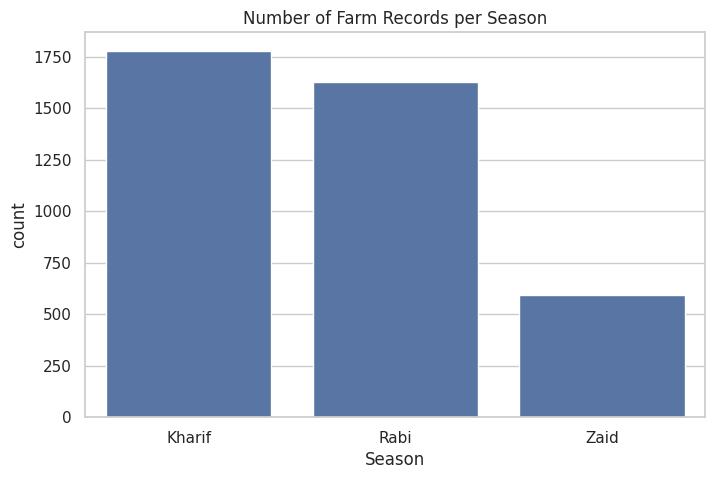

In [17]:
sns.countplot(x='Season', data=df, order=df['Season'].value_counts().index)
plt.title('Number of Farm Records per Season')
plt.show()

In [18]:
df.groupby('Season')[['Yield_Tonnes_Ha','Rainfall_mm','Avg_Temperature_C','Humidity_pct']].mean().round(2)

,Yield_Tonnes_Ha,Rainfall_mm,Avg_Temperature_C,Humidity_pct
Season,,,,
Kharif,2.25,849.20,28.45,71.81
Rabi,2.03,437.62,23.49,57.89
Zaid,1.81,304.65,31.04,52.01


## 5. How Does Yield Vary Across Seasons?

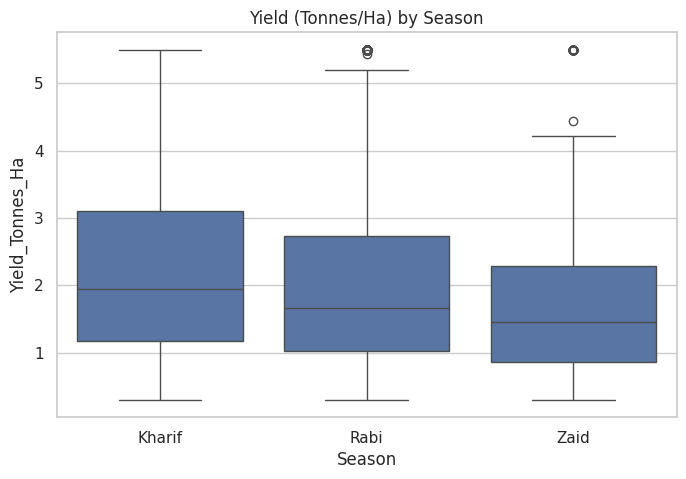

In [19]:
sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df)
plt.title('Yield (Tonnes/Ha) by Season')
plt.show()

/tmp/ipykernel_1737/3641690172.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Season', y='Yield_Tonnes_Ha', data=df, estimator=np.mean, ci=None)


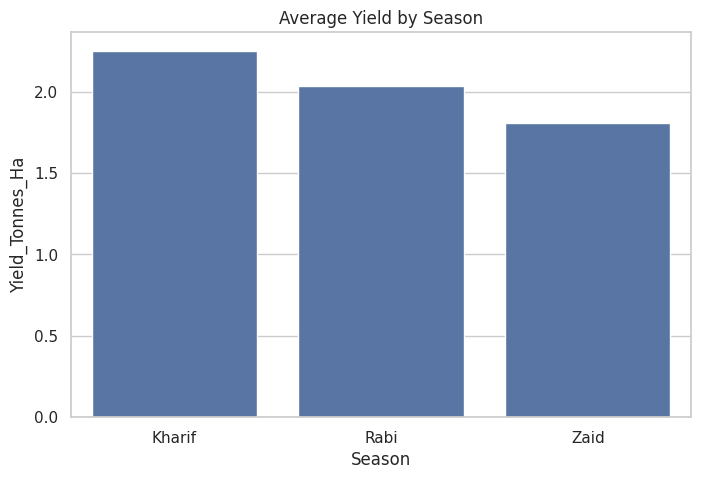

In [20]:
sns.barplot(x='Season', y='Yield_Tonnes_Ha', data=df, estimator=np.mean, ci=None)
plt.title('Average Yield by Season')
plt.show()

## 6. Environmental Conditions by Season

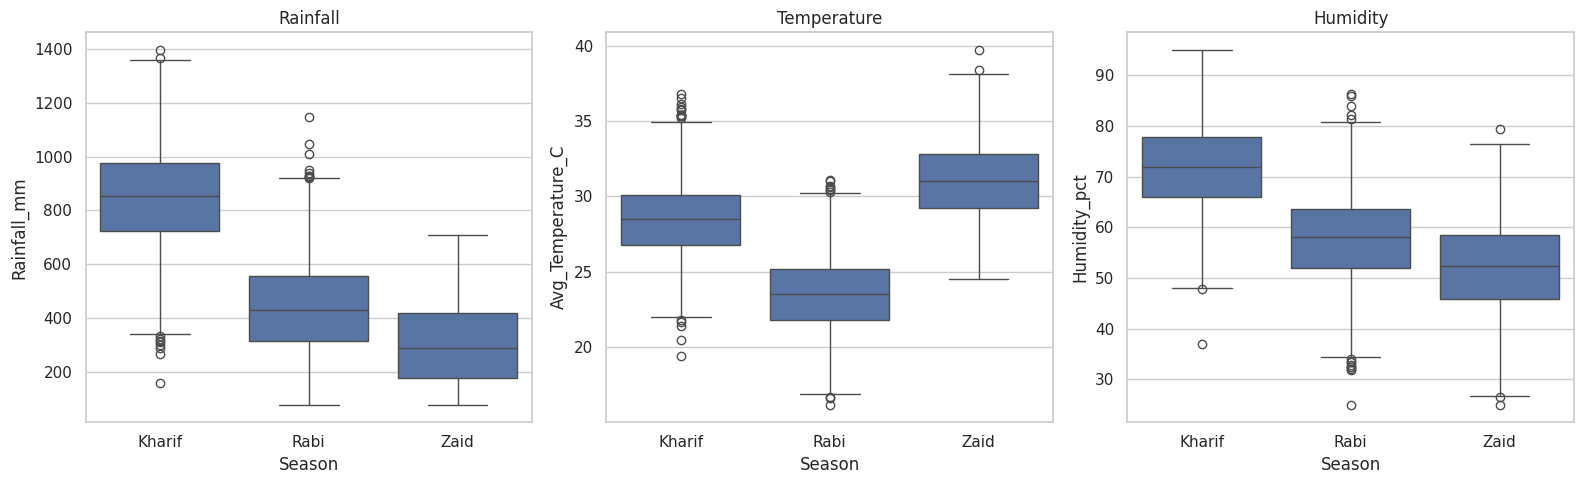

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
sns.boxplot(x='Season', y='Rainfall_mm', data=df, ax=axes[0])
sns.boxplot(x='Season', y='Avg_Temperature_C', data=df, ax=axes[1])
sns.boxplot(x='Season', y='Humidity_pct', data=df, ax=axes[2])
axes[0].set_title('Rainfall')
axes[1].set_title('Temperature')
axes[2].set_title('Humidity')
plt.tight_layout()
plt.show()

## 7. Resource Usage by Season

In [22]:
resource_cols = ['Fertilizer_kg_ha','Pesticide_Litre_ha','Water_Used_m3','Water_Efficiency_t_per_1000m3']
df.groupby('Season')[resource_cols].mean().round(2)

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.08,5.08,5680.51,5.89
Rabi,185.41,5.02,5505.50,5.19
Zaid,184.64,5.17,5999.48,4.41


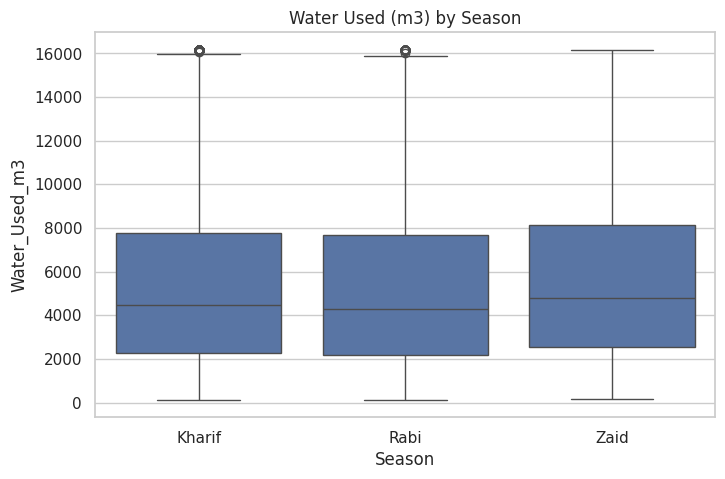

In [23]:
sns.boxplot(x='Season', y='Water_Used_m3', data=df)
plt.title('Water Used (m3) by Season')
plt.show()

## 8. Economic Performance by Season

In [24]:
econ_cols = ['Total_Cost_INR','Revenue_INR','Profit_INR']
df.groupby('Season')[econ_cols].mean().round(0)

,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,
Kharif,531804.0,710719.0,91728.0
Rabi,513837.0,601526.0,39060.0
Zaid,543977.0,519172.0,-51622.0


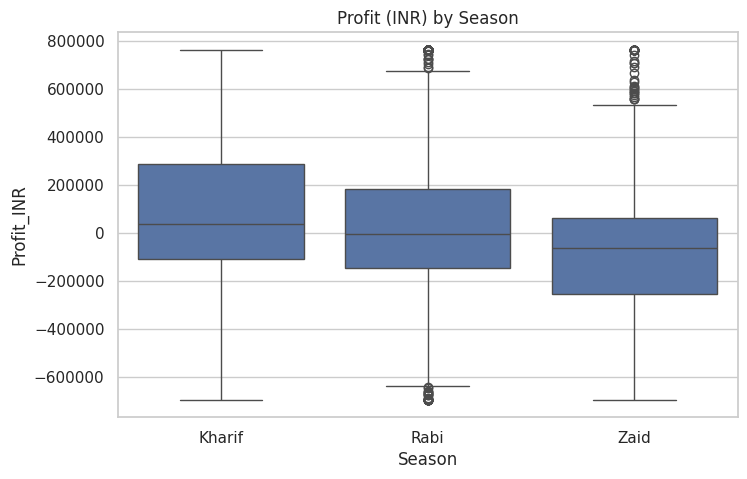

In [25]:
sns.boxplot(x='Season', y='Profit_INR', data=df)
plt.title('Profit (INR) by Season')
plt.show()

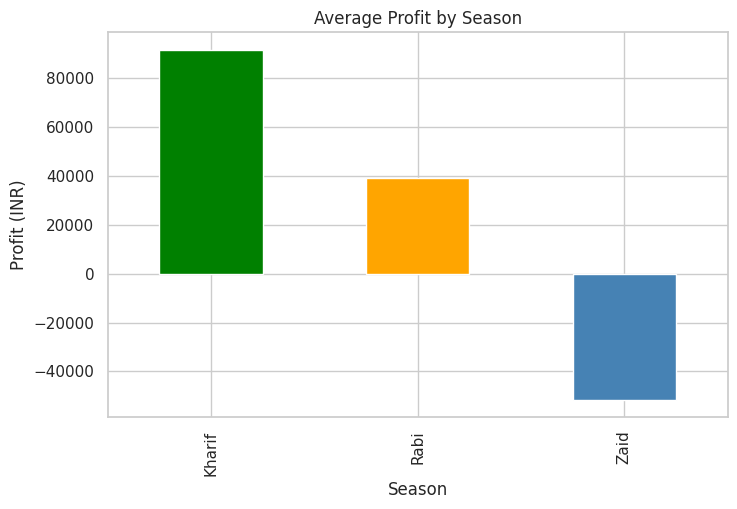

In [26]:
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)
season_profit.plot(kind='bar', color=['green','orange','steelblue'])
plt.title('Average Profit by Season')
plt.ylabel('Profit (INR)')
plt.show()

## 9. Best Performing Crops per Season

In [27]:
top_crops = df.groupby(['Season','Crop'])['Profit_INR'].mean().reset_index()
top_crops = top_crops.sort_values(['Season','Profit_INR'], ascending=[True, False])
top_crops.groupby('Season').head(3)

,Season,Crop,Profit_INR
6,Kharif,Sugarcane,526076.000000
0,Kharif,Chilli,457197.832432
1,Kharif,Cotton,197601.246512
14,Rabi,Sugarcane,436175.201550
8,Rabi,Chilli,392084.466258
9,Rabi,Cotton,97020.248756
22,Zaid,Sugarcane,400695.862745
16,Zaid,Chilli,325408.875000
17,Zaid,Cotton,-51136.804348


## 10. Correlation Between Numeric Features

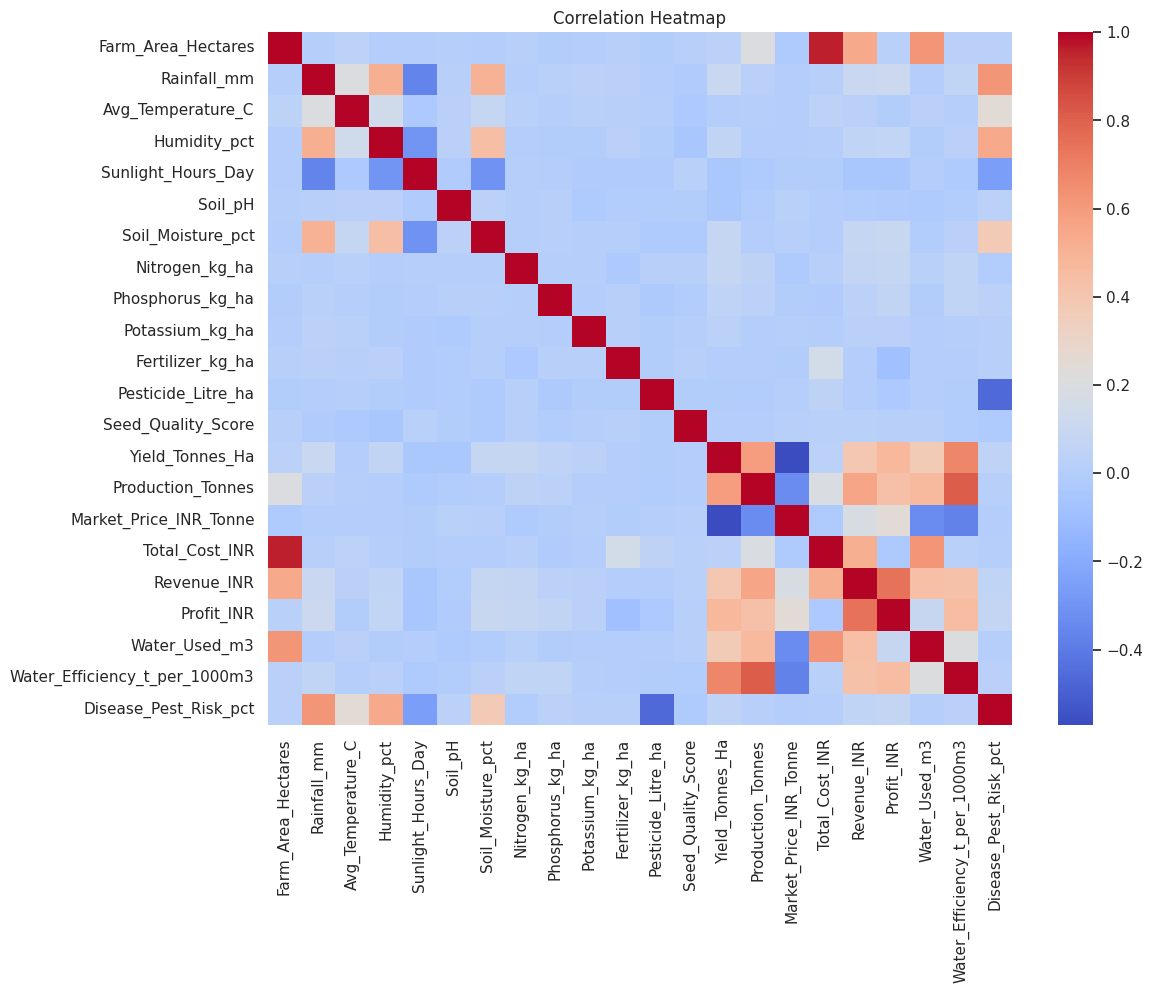

In [28]:
plt.figure(figsize=(12,9))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

In [29]:
corr['Yield_Tonnes_Ha'].sort_values(ascending=False)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.677372
Production_Tonnes,0.590416
Profit_INR,0.476238
Revenue_INR,0.392480
Water_Used_m3,0.370642
Rainfall_mm,0.100816
Soil_Moisture_pct,0.083093
Nitrogen_kg_ha,0.079882
Humidity_pct,0.065176


In [30]:
corr['Profit_INR'].sort_values(ascending=False)

,Profit_INR
Profit_INR,1.000000
Revenue_INR,0.742273
Yield_Tonnes_Ha,0.476238
Water_Efficiency_t_per_1000m3,0.448209
Production_Tonnes,0.433624
Market_Price_INR_Tonne,0.248264
Rainfall_mm,0.111283
Soil_Moisture_pct,0.095565
Water_Used_m3,0.089943
Nitrogen_kg_ha,0.085381


## 11. Is the Seasonal Difference Statistically Significant?

We use a **one-way ANOVA test** to check whether the mean Yield and mean Profit
genuinely differ across seasons, or if the differences we see could just be random noise.

- **H0 (Null Hypothesis):** Mean values are the same across all seasons.
- **H1 (Alternative Hypothesis):** At least one season has a different mean.
- If **p-value < 0.05**, we reject H0 — the seasonal difference is statistically significant.

In [31]:
kharif = df[df['Season']=='Kharif']['Yield_Tonnes_Ha']
rabi = df[df['Season']=='Rabi']['Yield_Tonnes_Ha']
zaid = df[df['Season']=='Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = stats.f_oneway(kharif, rabi, zaid)
print("Yield ANOVA -> F-statistic:", round(f_stat,3), " p-value:", round(p_value,5))

Yield ANOVA -> F-statistic: 25.043  p-value: 0.0


In [32]:
kharif_p = df[df['Season']=='Kharif']['Profit_INR']
rabi_p = df[df['Season']=='Rabi']['Profit_INR']
zaid_p = df[df['Season']=='Zaid']['Profit_INR']

f_stat2, p_value2 = stats.f_oneway(kharif_p, rabi_p, zaid_p)
print("Profit ANOVA -> F-statistic:", round(f_stat2,3), " p-value:", round(p_value2,5))

Profit ANOVA -> F-statistic: 39.465  p-value: 0.0


## 12. Does Irrigation Method Matter Across Seasons?

In [33]:
pivot = df.pivot_table(index='Season', columns='Irrigation_Method',
                        values='Yield_Tonnes_Ha', aggfunc='mean').round(2)
pivot

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,2.44,2.16,2.21,2.24
Rabi,2.27,1.99,1.88,2.04
Zaid,1.94,1.65,1.65,2.10


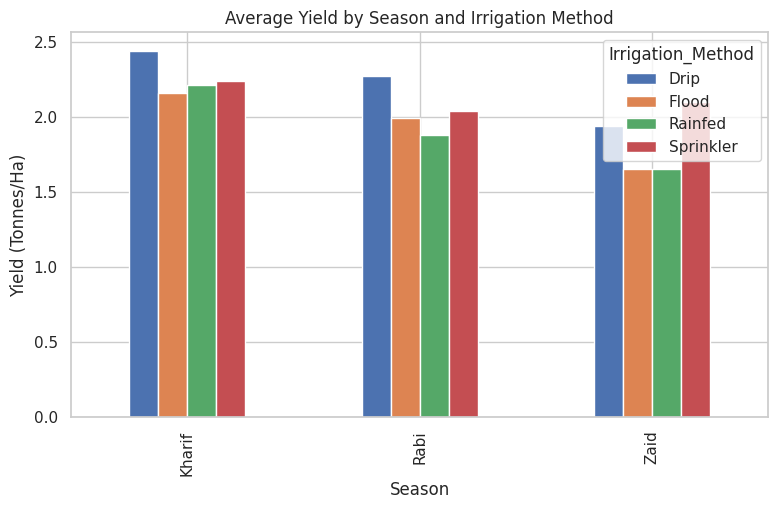

In [34]:
pivot.plot(kind='bar', figsize=(9,5))
plt.title('Average Yield by Season and Irrigation Method')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

## 13. Key Insights

- **Yield:** Kharif has the highest average yield (2.25 t/ha), followed by Rabi (2.03 t/ha)
  and Zaid (1.81 t/ha). Kharif outperforms Zaid by roughly 25%.
- **Environment:** Kharif gets far more rainfall (849 mm) and higher humidity (72%) than
  Rabi (438 mm, 58%) and Zaid (305 mm, 52%). Zaid is the hottest season (31°C avg) but
  the driest, which likely explains its lower yield despite similar input levels.
- **Resources:** Zaid uses the most water (6000 m³) but has the lowest water efficiency
  (4.41 tonnes per 1000 m³), while Kharif is the most water-efficient (5.89 t/1000m³) —
  natural rainfall is doing more of the work in Kharif.
- **Economics:** Kharif is by far the most profitable season on average (₹91,700/farm),
  Rabi is moderately profitable (₹39,000/farm), and Zaid runs at an average **loss**
  (-₹51,600/farm) — high water/resource costs in a low-yield, high-heat season eat into returns.
- **Statistical significance:** One-way ANOVA gives p < 0.001 for both Yield and Profit across
  seasons — the seasonal differences are statistically significant, not random noise.
- **Crops:** Sugarcane is the top profit-earner in every season, but profit still declines
  sharply from Kharif → Rabi → Zaid even for the same crop, confirming the effect is seasonal,
  not just a crop mix issue.
- **Irrigation:** Drip irrigation gives the best yield in every season, and the yield gap
  between irrigation methods is widest in Zaid — irrigation choice matters most when natural
  rainfall is scarcest.


## 14. Conclusions & Recommendations

1. **Prioritize Kharif for high-value/water-intensive crops** — it combines the best yield,
   best profit, and best water efficiency of the three seasons.
2. **Zaid needs intervention, not avoidance** — since it currently runs at a loss, farms
   continuing to cultivate in Zaid should shift toward Drip irrigation (it shows the largest
   relative yield benefit here) and prioritize heat/drought-tolerant, high-margin crops
   like Sugarcane over low-margin options.
3. **Improve water efficiency in Zaid specifically** — it uses the most water but returns the
   least yield per unit of water; efficiency here should be a stakeholder priority.
4. **Use Rabi as the balanced middle season** — moderate profit and yield with lower resource
   costs than Kharif; consider it for medium-risk crop choices.

**Limitations:** This dataset is a single-cycle cross-section (no year-over-year trend), and
region/district-level effects (soil type, local pricing) are not fully isolated from the
seasonal effect in this analysis. A multi-year dataset and a regression model isolating
season vs. region vs. crop effects would strengthen these conclusions further.
